<a href="https://colab.research.google.com/github/paulagirones/Aerogels_thermal_conductivity/blob/main/aerogels_thermal_conductivity_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aerogels thermal conductivity

RAW DATA
   ↓
DATA CLEANING              ← ESTÁS AQUÍ
   ↓
EDA                        ← SIGUIENTE
   ↓
FEATURE SELECTION
   ↓
TRAIN / TEST SPLIT
   ↓
ML PREPROCESSING
   ↓
BASELINE MODEL
   ↓
MODEL COMPARISON
   ↓
FEATURE IMPORTANCE
   ↓
FINAL MODEL

# DATA EXPLORATION

In [63]:
import pandas as pd
import numpy as np

# Load the dataset
df_raw = pd.read_csv('20250220_dataset.csv')

# Working copy
df = df_raw.copy()
# Inspect the first rows
print("First 5 rows:")
display(df.head())

# Display information about the dataset
print("\nDataset information:")
df.info()



First 5 rows:


,Entry,Drying,Purpose,Shape,First materials,Second materials,Modification,First material class,Second materials class,Modification class,...,BET surface area m2/g,BJH pore size nm,BJH pore volume (total) cm3/g,compression elastic modulus MPa,SEM,Thermal conductivity W/(m K),Thermal method,Thermal method detail,Unnamed: 28,Unnamed: 29
0,1,SCD,Not specific,Monolith?,Soda soap,NaN,NaN,Q,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,185.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,185.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16559 entries, 0 to 16558
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entry                            16559 non-null  int64  
 1   Drying                           16559 non-null  object 
 2   Purpose                          16559 non-null  object 
 3   Shape                            16559 non-null  object 
 4   First materials                  16559 non-null  object 
 5   Second materials                 6368 non-null   object 
 6   Modification                     3086 non-null   object 
 7   First material class             16559 non-null  object 
 8   Second materials class           6368 non-null   object 
 9   Modification class               3082 non-null   object 
 10  Gelation class                   16559 non-null  object 
 11  Solvent class                    16559 non-null  object 
 

# CLEANING

In [64]:
# Check Porosity type
print('Porosity type:')
print(df['Porosity'].dtype)
print(df['Porosity'].unique()[:20])

# Check SEM type
print('SEM type:')
print(df['SEM'].dtype)
print(df['SEM'].unique()[:20])


# Check Unnamed:29 type and content
print('Unnamed: 29 column content:')
print(df['Unnamed: 29'].dtype)
print(df['Unnamed: 29'].unique())


Porosity type:
object
[nan '95%' '94%' '98%' '96%' '97%' '65%' '74.38%' '80.75%' '84.19%'
 '88.06%' '87.45%' '82.64%' '78.32%' '67.97%' '32.80%' '48.20%' '53.70%'
 '59.30%' '65.90%']
SEM type:
object
[nan 'Mesoporous (nanoparticulate)' 'Macroporous (cellular)' 'Mesoporous?'
 'Macroporous (flakes)' 'Macroporous (particulate)'
 'Macroporous (fibrous)' 'Macroporous (fibrous and particulate)'
 'Mesoporous (nanofibrous)' 'Microparticles'
 'Macroporous (cellular and fibrous)'
 'Mesoporous (nanofibrous and nanoparticulate)'
 'Macroporous (cellular and flakes)' 'Macroporous (fibrous and flakes)'
 'Macroporous (nanoparticulate)' 'Macroporous (cellular and particulate)'
 'Macroporous (flakes and particulate)' 'Macroporous' 'Macroporous?'
 'Macroporous (nanofibrous)']
Unnamed: 29 column content:
object
[nan 'kokoko' 'koko' 'kokokoko' 'kokokokoko']


In [65]:
#Fix porosity type (it is numeric)
df['Porosity'] = (
    df['Porosity']
    .str.replace('%', '', regex=False)
    .astype(float)
)

display(df.loc[df['Porosity'].notna(), ['Porosity']].head(10))

# Remove empty and wrong columns
df = df.drop(columns=['Unnamed: 28', 'Unnamed: 29'])

,Porosity
148,95.0
149,95.0
150,95.0
151,94.0
239,98.0
240,96.0
241,97.0
242,98.0
243,97.0
244,95.0


In [66]:
# Check missing values
missing = pd.DataFrame({
    'Missing values': df.isna().sum(),
    'Missing (%)': df.isna().mean() * 100
})
display(missing.sort_values('Missing (%)', ascending=False))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

,Missing values,Missing (%)
Post-drying cross-linking,16064,97.010689
BJH pore size nm,15547,93.888520
BJH pore volume (total) cm3/g,14080,85.029289
Thermal conductivity W/(m K),14075,84.999094
Thermal method detail,14069,84.962860
Thermal method,14066,84.944743
compression elastic modulus MPa,13558,81.876925
Modification class,13477,81.387765
Modification,13473,81.363609
Post drying treatment,13264,80.101455


Duplicate rows: 0


In [67]:
#Rename columns
df = df.rename(columns={
    'Thermal conductivity W/(m K)': 'Thermal_conductivity',
    'Envelope density g/cm3': 'Density',
    'BET surface area m2/g': 'BET',
    'BJH pore size nm': 'Pore_size',
    'BJH pore volume (total) cm3/g': 'Pore_volume',
    'compression elastic modulus MPa': 'Elastic_modulus'
})

# Remove samples without a measured thermal conductivity (our target)
df = df.dropna(subset=['Thermal_conductivity'])

# Display categories and number of unique values
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(f"Number of categories: {df[col].nunique()}")
    print(df[col].unique()[:10])


--- Drying ---
Number of categories: 5
['SCD' 'FD' 'APD' 'VD' 'Foaming']

--- Purpose ---
Number of categories: 28
['Thermal insulation' 'Not specific'
 'Sound insulation, thermal insulation' 'Adsorbent' 'Filters' 'Separation'
 'Adsorbent (gas)' 'Thermoelectric devices' 'Steam generation'
 'Separation, thermal insulation']

--- Shape ---
Number of categories: 11
['Monolith' 'Fibers, monolith' 'Monolith ' 'Sheet' 'Fibers'
 'Monolith, sheet' 'Monolith (3D)' 'Beads, monolith' 'Beads' 'FIbers']

--- First materials ---
Number of categories: 90
['RF' 'Phenolic resin' 'Polyisocyanurate' 'Polyurethane'
 'Polydicyclopentadiene' 'Poly(urea-urethane)' 'Aramid fibers' 'Polyimide'
 'Lignocellulose' 'Cellulose']

--- Second materials ---
Number of categories: 123
[nan 'PVA, GO' 'Lignin' 'PMMA' 'Aramid' 'Silicone resin'
 'Silicone resin, cork' 'Phenolic resin' 'Starch' 'SiO2']

--- Modification ---
Number of categories: 63
[nan 'MTMS treatment' 'Fluorosilan modification' 'Carbonized'
 '3-Aminopropy

In [68]:
# Remove leading and trailing whitespace from categorical variables
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].str.strip()

# Check for inconsistencies caused by capitalization
for col in categorical_columns:
    normalized = (
        df[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

    print(
        f"{col}: "
        f"{df[col].nunique()} original -> "
        f"{normalized.nunique()} normalized categories"
    )

Drying: 5 original -> 5 normalized categories
Purpose: 28 original -> 27 normalized categories
Shape: 10 original -> 9 normalized categories
First materials: 90 original -> 90 normalized categories
Second materials: 123 original -> 122 normalized categories
Modification: 63 original -> 63 normalized categories
First material class: 16 original -> 16 normalized categories
Second materials class: 56 original -> 56 normalized categories
Modification class: 7 original -> 7 normalized categories
Gelation class: 9 original -> 9 normalized categories
Solvent class: 8 original -> 8 normalized categories
Process: 2193 original -> 2193 normalized categories
Gelation mechanism: 29 original -> 28 normalized categories
Final solvent: 31 original -> 31 normalized categories
Drying details: 12 original -> 12 normalized categories
Post drying treatment: 136 original -> 136 normalized categories
Post-drying cross-linking: 3 original -> 3 normalized categories
SEM: 20 original -> 20 normalized categorie

In [69]:
# Find categories that differ only by capitalization

for col in categorical_columns:

    normalized = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
    )

    temp = pd.DataFrame({
        'original': df[col],
        'normalized': normalized
    }).drop_duplicates()

    duplicates = (
        temp.groupby('normalized')['original']
        .agg(list)
    )

    duplicates = duplicates[
        duplicates.apply(lambda x: len(x) > 1)
    ]

    if not duplicates.empty:
        print(f"\n--- {col} ---")
        for normalized_value, original_values in duplicates.items():
            print(f"{original_values} -> '{normalized_value}'")


--- Purpose ---
['Separation, thermal insulation', 'Separation, thermal Insulation'] -> 'separation, thermal insulation'

--- Shape ---
['Fibers', 'FIbers'] -> 'fibers'

--- Second materials ---
['Aramid fibers, MXene', 'Aramid fibers, Mxene'] -> 'aramid fibers, mxene'

--- Gelation mechanism ---
['No gelation', 'NO gelation'] -> 'no gelation'

--- Thermal method detail ---
['Hot disk', 'hot disk'] -> 'hot disk'


In [70]:
# Correct inconsistent categorical values

corrections = {
    'Purpose': {
        'Separation, thermal Insulation': 'Separation, thermal insulation'
    },
    'Shape': {
        'FIbers': 'Fibers'
    },
    'Second materials': {
        'Aramid fibers, Mxene': 'Aramid fibers, MXene'
    },
    'Gelation mechanism': {
        'NO gelation': 'No gelation'
    },
    'Thermal method detail': {
        'hot disk': 'Hot disk'
    }
}

for col, replacements in corrections.items():
    df[col] = df[col].replace(replacements)

In [71]:
# Check categorical variables after corrections

for col in corrections:
    print(f"\n--- {col} ---")
    print(f"Number of categories: {df[col].nunique()}")
    print(df[col].value_counts())
    # Check for remaining capitalization inconsistencies

for col in categorical_columns:
    normalized = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
    )

    print(
        f"{col}: "
        f"{df[col].nunique()} original categories -> "
        f"{normalized.nunique()} normalized categories"
    )


--- Purpose ---
Number of categories: 27
Purpose
Thermal insulation                               1808
Not specific                                      184
Steam generation                                   58
Separation, thermal insulation                     57
Sound insulation, thermal insulation               54
Separation                                         34
PCM support                                        33
Shield                                             33
Optoelectronic devices                             32
Sound insulation                                   25
Filters                                            23
Shield, thermal insulation                         19
Scaffold, thermal insulation                       18
Filters, thermal insulation                        16
Adsorbent, thermal insulation                      16
Thermoelectric devices                             15
Packaging                                          13
Adsorbent                       

In [77]:
# Display information about the dataset after cleaning
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 2484 entries, 30 to 16544
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Entry                      2484 non-null   int64  
 1   Drying                     2484 non-null   object 
 2   Purpose                    2484 non-null   object 
 3   Shape                      2484 non-null   object 
 4   First materials            2484 non-null   object 
 5   Second materials           888 non-null    object 
 6   Modification               305 non-null    object 
 7   First material class       2484 non-null   object 
 8   Second materials class     888 non-null    object 
 9   Modification class         301 non-null    object 
 10  Gelation class             2484 non-null   object 
 11  Solvent class              2484 non-null   object 
 12  Process                    2484 non-null   object 
 13  Gelation mechanism         24

# EXPLORATORY DATA ANALYSIS (EDA)

count    2484.000000
mean        0.050934
std         0.152535
min         0.010000
25%         0.028522
50%         0.036550
75%         0.048000
max         7.000000
Name: Thermal_conductivity, dtype: float64


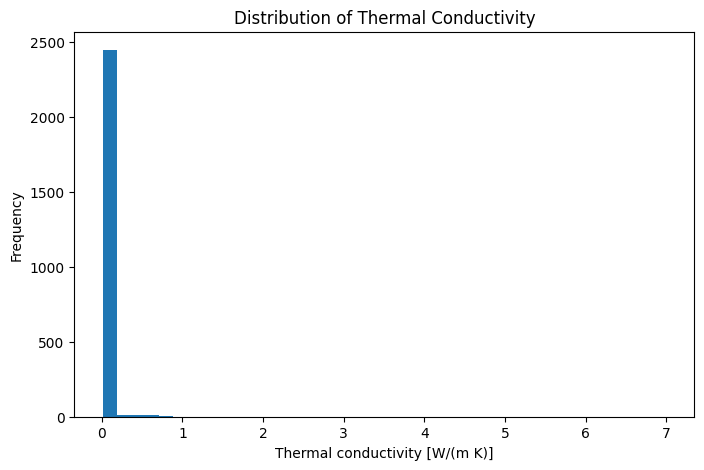

Values between 0 and 1: 2483
Total values: 2484
Percentage between 0 and 1: 99.96%


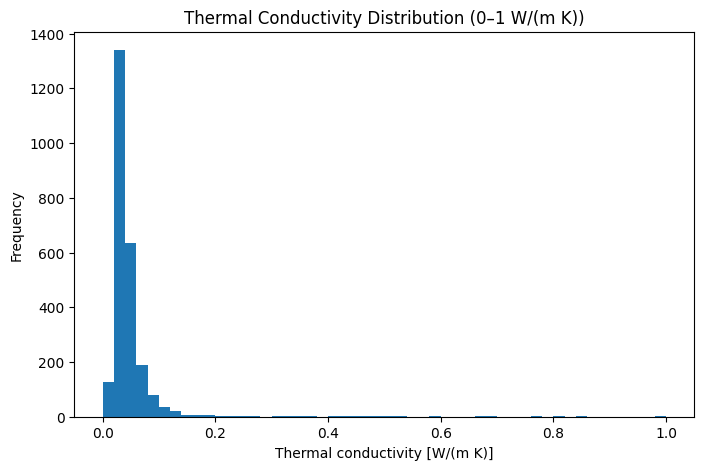

In [78]:
# Basic statistics of the target variable
print(df['Thermal_conductivity'].describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['Thermal_conductivity'], bins=40)

plt.xlabel('Thermal conductivity [W/(m K)]')
plt.ylabel('Frequency')
plt.title('Distribution of Thermal Conductivity')

plt.show()

# Count values between 0 and 1
count_0_1 = df['Thermal_conductivity'].between(0, 1).sum()

print(f'Values between 0 and 1: {count_0_1}')
print(f'Total values: {df["Thermal_conductivity"].notna().sum()}')
print(
    f'Percentage between 0 and 1: '
    f'{count_0_1 / df["Thermal_conductivity"].notna().sum() * 100:.2f}%'
)

plt.figure(figsize=(8, 5))

plt.hist(
    df['Thermal_conductivity'].dropna(),
    bins=50,
    range=(0, 1)
)

#We only have one value that is >1

plt.xlabel('Thermal conductivity [W/(m K)]')
plt.ylabel('Frequency')
plt.title('Thermal Conductivity Distribution (0–1 W/(m K))')

plt.show()



In [81]:
numerical_features = [
    'Thermal_conductivity',
    'Density',
    'Porosity',
    'BET',
    'Pore_size',
    'Pore_volume',
    'Elastic_modulus'
]

display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Thermal_conductivity,2484.0,0.050934,0.152535,0.0100,0.028522,0.03655,0.048,7.00
Density,2210.0,0.129133,0.137704,0.0005,0.035000,0.08870,0.170,1.15
Porosity,1405.0,89.493559,10.515960,17.7000,86.000000,92.30000,96.900,99.97
BET,959.0,207.128367,164.915259,0.0630,64.000000,188.00000,310.500,966.00
Pore_size,160.0,25.290625,14.640818,0.0500,15.000000,20.60000,32.700,66.00
Pore_volume,318.0,1.159815,1.245880,0.0030,0.380000,0.80450,1.500,8.41
Elastic_modulus,827.0,25.851266,100.113102,0.0001,0.150000,1.72000,13.250,1557.00


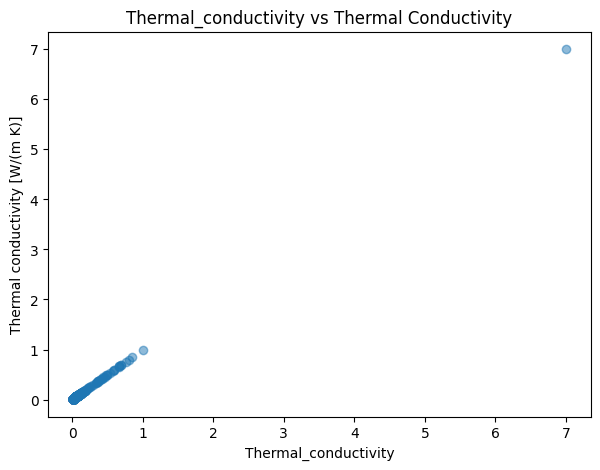

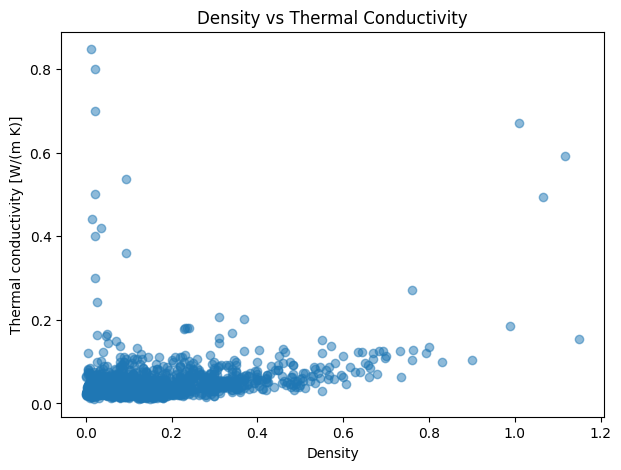

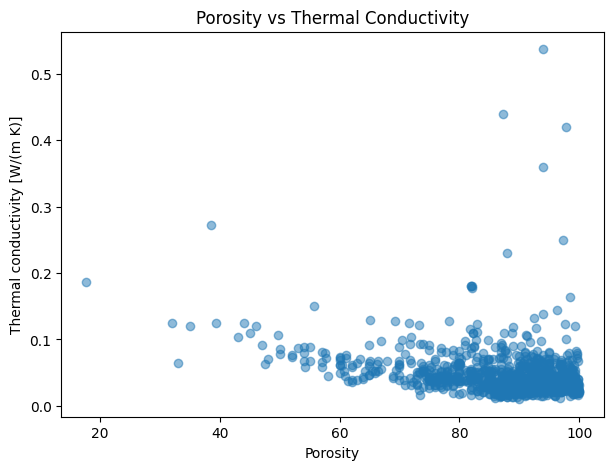

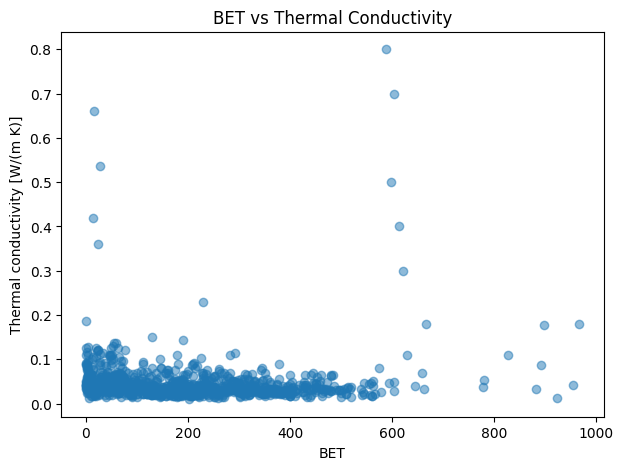

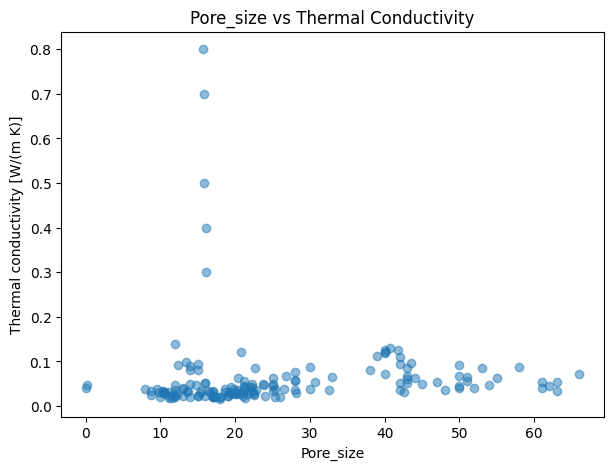

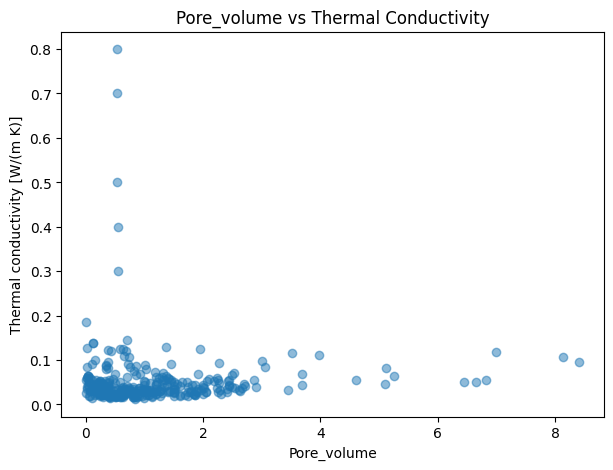

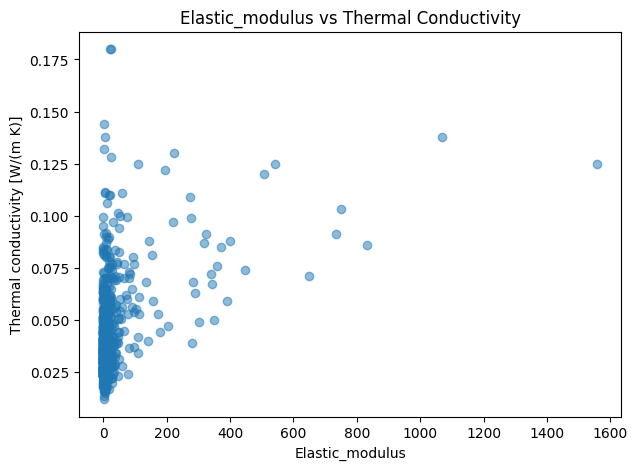

In [86]:
for col in numerical_features:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        df[col],
        df['Thermal_conductivity'],
        alpha=0.5
    )

    plt.xlabel(col)
    plt.ylabel('Thermal conductivity [W/(m K)]')
    plt.title(f'{col} vs Thermal Conductivity')

    plt.show()

It can be seen some tendecies when density and porosity are represented.

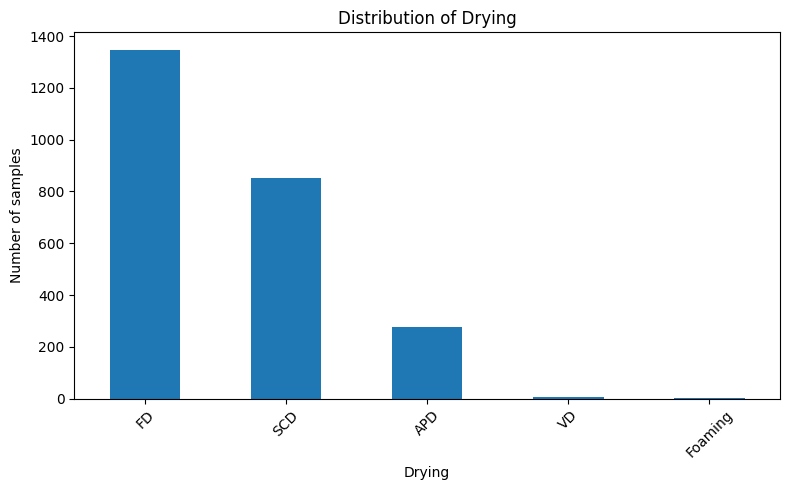

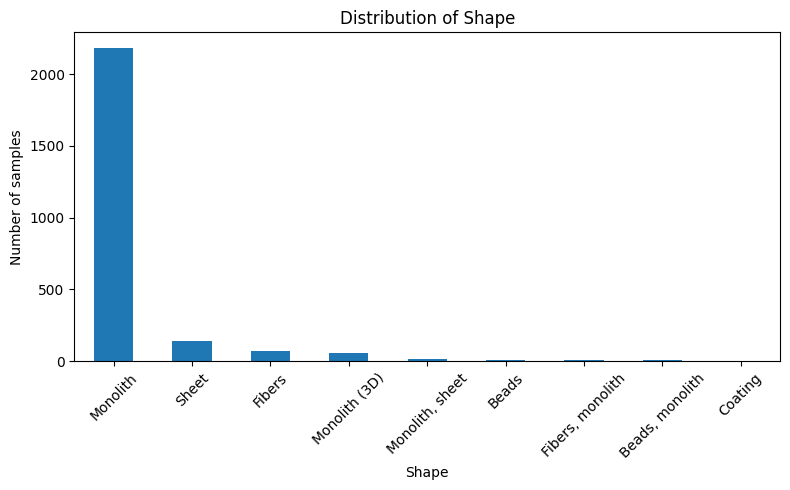

In [93]:
categorical_features = [
    'Drying',
    'Shape'
]

for col in categorical_features:
    plt.figure(figsize=(8, 5))

    df[col].value_counts().plot(kind='bar')

    plt.xlabel(col)
    plt.ylabel('Number of samples')
    plt.title(f'Distribution of {col}')

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

Some Shape values contain multiple forms (e.g., "Monolith, sheet"). Treating them as single categories is not an ideal representation. We will address this later by converting Shape into separate binary features. This also happens to other features like purpose.

<Figure size 800x500 with 0 Axes>

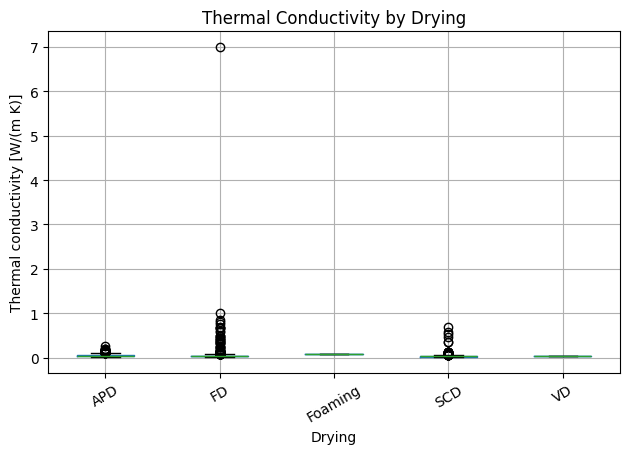

<Figure size 800x500 with 0 Axes>

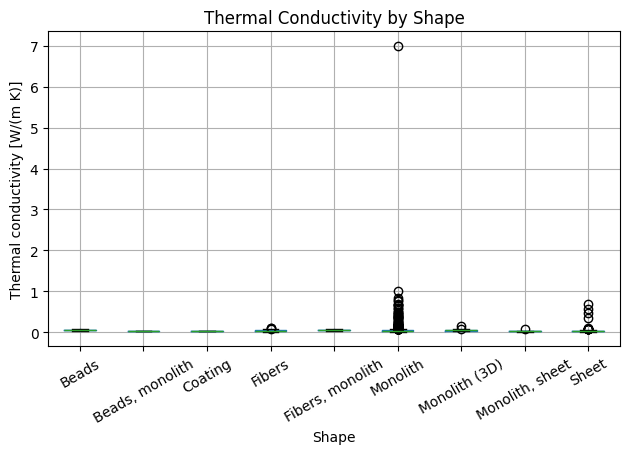

In [92]:
for col in ['Drying', 'Shape']:
    plt.figure(figsize=(8, 5))

    df.boxplot(
        column='Thermal_conductivity',
        by=col
    )

    plt.xlabel(col)
    plt.ylabel('Thermal conductivity [W/(m K)]')
    plt.title(f'Thermal Conductivity by {col}')

    plt.suptitle('')
    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.show()

In [114]:
# Display the highest thermal conductivity values
display(
    df[['Thermal_conductivity', 'First materials', 'Drying', 'Shape']]
    .sort_values('Thermal_conductivity', ascending=False)
    .head(20)
)

,Thermal_conductivity,First materials,Drying,Shape
6642,7.000,GO,FD,Monolith
6641,1.000,GO,FD,Monolith
4518,0.847,GO,FD,Monolith
9328,0.800,Cellulose nanofibers,FD,Monolith
9309,0.760,GO,FD,Monolith
3731,0.700,GO,SCD,Sheet
9327,0.700,Cellulose nanofibers,FD,Monolith
6475,0.670,GO,FD,Monolith
9310,0.670,GO,FD,Monolith
14001,0.660,Polypyrrole,FD,Monolith


It is important to understand how is related first materials and first materials class

In [113]:
# Display material and corresponding class

material_class_mapping = (
    df[['First materials', 'First material class']]
    .drop_duplicates()
)

display(material_class_mapping)

# Find materials associated with multiple classes

multiple_classes = (
    df.groupby('First materials')['First material class']
    .nunique()
)

print('Number of materials with more than 1 class:')
print(len(multiple_classes[multiple_classes > 1]))

print('Number of materials without a class:')
print(len(multiple_classes[multiple_classes < 1]))


,First materials,First material class
30,RF,I
264,Phenolic resin,I
388,Polyisocyanurate,H
482,Polyurethane,H
853,Polydicyclopentadiene,M
...,...,...
15907,Poly(amic acid),G
15931,"Poly(2,5-dihydroxy-1,4-phenylene pyridine diim...",K
16015,Trimethoxybenzene-formaldehyde,I
16381,Carbon fibers,L


Number of materials with more than 1 class:
0
Number of materials without a class:
0
